In [5]:
import os
import glob
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from skimage import feature

In [6]:
start_date = "2011-08-21T00:00:00"
start_date = datetime.strptime(start_date, "%Y-%m-%dT%H:%M:%S")
end_date = "2011-08-30T00:00:00"
end_date=datetime.strptime(end_date, "%Y-%m-%dT%H:%M:%S")
time_delta = 24
time_range = pd.date_range(start_date, end_date, freq=f"{time_delta}h").strftime('%Y-%m-%dT%H:%M:%S').to_list()
time_range
time_days = pd.date_range(start_date, end_date, freq=f"{time_delta}h").strftime('%d/%m').to_list()

In [7]:
data_path = "/glade/derecho/scratch/turuncu/data/Data_aurora/data_6h"
files = sorted(glob.glob(os.path.join(data_path, "*_surface-level-accum.nc")))
ds_era5 = xr.open_mfdataset(files, data_vars="all", chunks='auto', engine="netcdf4")[["tp"]]
ds_era5 = ds_era5.rename({'valid_time': 'time'})
ds_era5_daily = ds_era5.resample(time='1D').mean().sel(time=time_range)
ds_era5_daily

<xarray.Dataset> Size: 42MB
Dimensions:    (time: 10, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 80B 2011-08-21 2011-08-22 ... 2011-08-30
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number     int64 8B 0
    expver     <U4 16B '0001'
Data variables:
    tp         (time, latitude, longitude) float32 42MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-12-14T04:07 GRIB to CDM+CF via cfgrib-0.9.1...

In [8]:
data_path = "/glade/derecho/scratch/turuncu/data/datasets/precip/cmorph"
files = sorted(glob.glob(os.path.join(data_path, "CMORPH_V1.0_ADJ_0.25deg-DLY_*.nc")))
ds_cmorph = xr.open_mfdataset(files, data_vars="all", chunks='auto', engine="netcdf4")
ds_cmorph = ds_cmorph.isel(nv=1).sel(time=time_range)
ds_cmorph

<xarray.Dataset> Size: 28MB
Dimensions:      (time: 10, lat: 480, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 80B 2011-08-21 2011-08-22 ... 2011-08-30
  * lat          (lat) float32 2kB -59.88 -59.62 -59.38 ... 59.38 59.62 59.88
  * lon          (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    time_bounds  (time) datetime64[ns] 80B dask.array<chunksize=(1,), meta=np.ndarray>
    lat_bounds   (time, lat) float32 19kB dask.array<chunksize=(1, 480), meta=np.ndarray>
    lon_bounds   (time, lon) float32 58kB dask.array<chunksize=(1, 1440), meta=np.ndarray>
    cmorph       (time, lat, lon) float32 28MB dask.array<chunksize=(1, 480, 1440), meta=np.ndarray>
Attributes: (12/57)
    ncei_template_version:      NCEI_NetCDF_Grid_template_V2.0
    title:                      NOAA Climate Data Record (CDR) of CPC Morphin...
    keywords:                   Precipitation, Satellite, High-Resolution, Gl...
    summary:                    The CMORPH CDR is a reprocessed and bias-corr...
    references:                 Xie, P., et al. (2017), Reprocessed, Bias-Cor...
    Conventions:                CF-1.6, ACDD-1.3
    ...                         ...
    geospatial_lat_resolution:  0.25
    geospatial_lat_units:       degrees_north
    geospatial_lon_min:         0.0
    geospatial_lon_max:         360.0
    geospatial_lon_resolution:  0.25
    geospatial_lon_units:       degrees_east

In [28]:
# Combine predictions
lead_time = 2
epoch_date = pd.Timestamp("1970-01-01") 
aurora_path = '/glade/derecho/scratch/turuncu/data/Data_aurora/predictions_irene_tp'
files = sorted(glob.glob(os.path.join(aurora_path, "pred_*.nc")))
var_list = ['tp']

ds = []
for f in files:
    d = datetime.strptime(os.path.basename(f)[5:-3], "%Y-%m-%dT%H:%M:%S")
    #print(f, d)
    ds_tmp = xr.open_dataset(f).drop_vars("rollout_step").rename({'time': 'lead_time', 'batch': 'time'})[var_list]
    ds_tmp = ds_tmp.isel(lead_time=lead_time)
    time_since_epoch = (d - epoch_date).total_seconds()
    ds_tmp = ds_tmp.assign_coords(time=[pd.to_datetime(time_since_epoch, unit='s')])
    ds_tmp.time.attrs['units'] = "seconds since 1970-01-01"
    ds_tmp.time.attrs['calendar'] = "gregorian"
    ds.append(ds_tmp)

ds_combined = xr.concat(ds, join='exact', dim='time')
ds_combined_daily = ds_combined.resample(time='1D').mean().sel(time=time_range)
ds_combined_daily

/glade/derecho/scratch/turuncu/tmp/ipykernel_78897/544701708.py:20: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_combined = xr.concat(ds, join='exact', dim='time')


<xarray.Dataset> Size: 41MB
Dimensions:    (time: 10, latitude: 720, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 80B 2011-08-21 2011-08-22 ... 2011-08-30
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.25 -89.5 -89.75
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    tp         (time, latitude, longitude) float32 41MB 2.526e-09 ... 1.092e-09

In [29]:
# Get best track data
import tropycal.tracks as tracks
basin = tracks.TrackDataset(basin='north_atlantic', source='hurdat', include_btk=True)
storm = basin.get_storm(("irene", 2011))
storm

--> Starting to read in HURDAT2 data
--> Completed reading in HURDAT2 data (1.58 seconds)
--> Starting to read in best track data
--> Completed reading in best track data (3.64 seconds)


<tropycal.tracks.Storm>
Storm Summary:
    Maximum Wind:      105 knots
    Minimum Pressure:  942 hPa
    Start Time:        0000 UTC 21 August 2011
    End Time:          1800 UTC 28 August 2011

Variables:
    time        (datetime) [2011-08-21 00:00:00 .... 2011-08-30 00:00:00]
    extra_obs   (int64) [0 .... 0]
    special     (str) [ .... ]
    type        (str) [TS .... EX]
    lat         (float64) [15.0 .... 53.0]
    lon         (float64) [-59.0 .... -60.0]
    vmax        (int64) [45 .... 40]
    mslp        (int64) [1006 .... 991]
    wmo_basin   (str) [north_atlantic .... north_atlantic]

More Information:
    id:              AL092011
    operational_id:  AL092011
    name:            IRENE
    year:            2011
    season:          2011
    basin:           north_atlantic
    source_info:     NHC Hurricane Database
    source:          hurdat
    ace:             18.8
    realtime:        False
    invest:          False
    subset:          False

In [30]:
# Define bounding box limits
min_lat, max_lat = 13, 47
min_lon, max_lon = 275, 305

# Create figure with cartopy projection
projection = ccrs.LambertConformal(
    central_longitude=(min_lon+max_lon)/2.0,
    central_latitude=(min_lat+max_lat)/2.0,
    standard_parallels=(20.0, 40.0)
)

# Set min, max
vmin, vmax = 0, 150
thold = 10

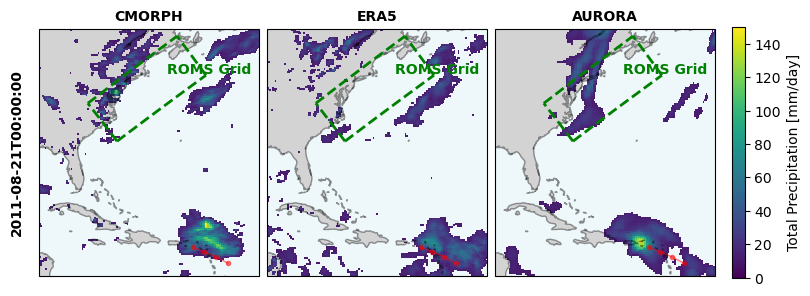

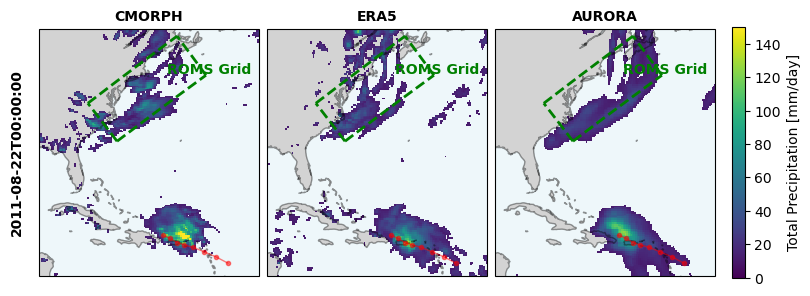

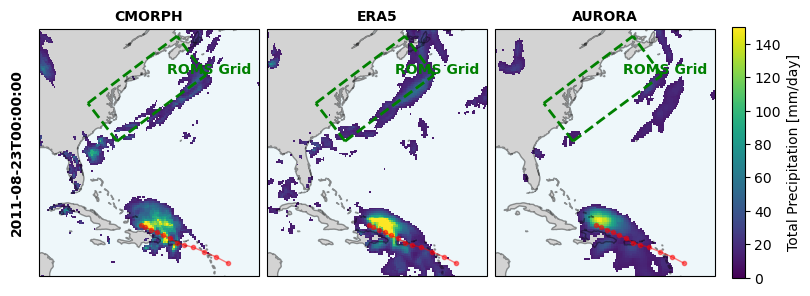

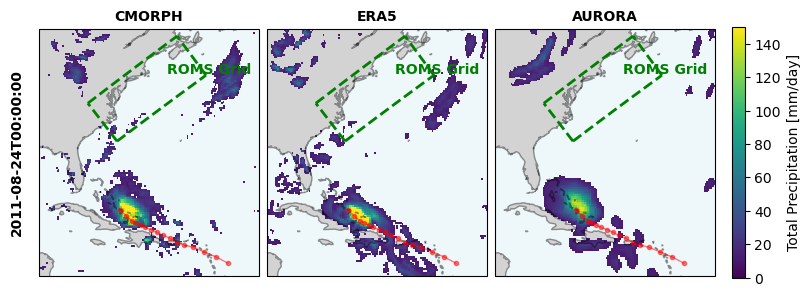

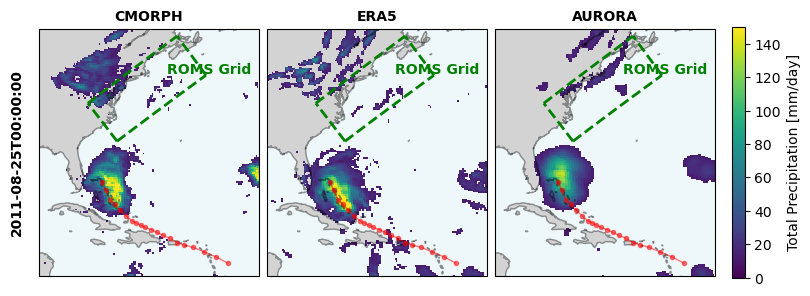

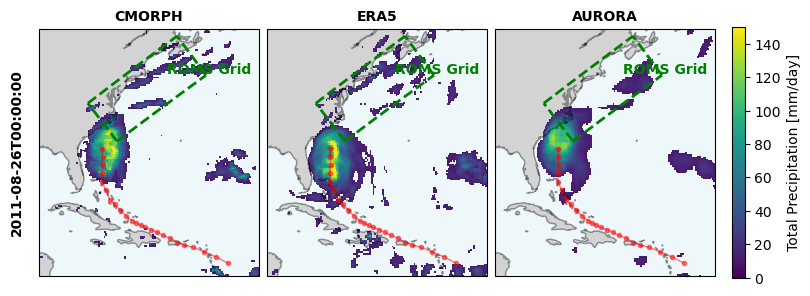

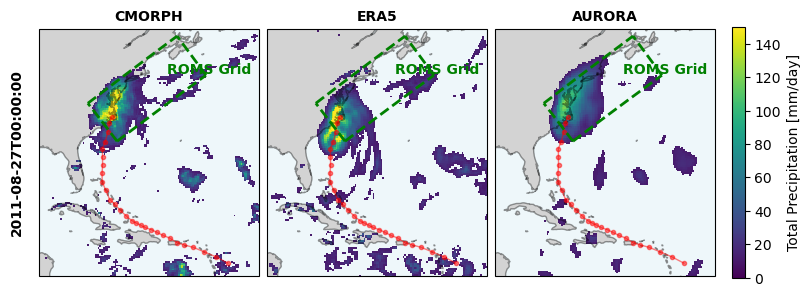

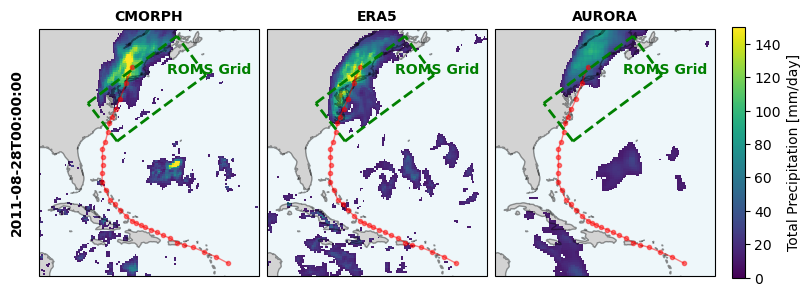

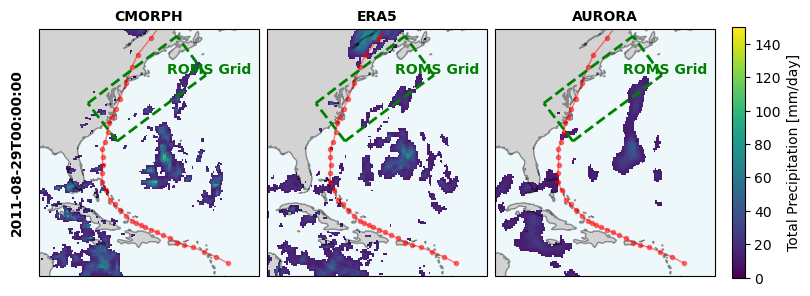

In [31]:
# Loop over time steps
for t in range(0, len(ds_cmorph.time.values)-1):
    # Create figure
    fig, axs = plt.subplots(1, 3, figsize=(8,3), layout='constrained', subplot_kw={'projection': projection})

    # Add map features
    for ax in axs.flat:
        # Add coastline etc.
        ax.add_feature(cfeature.COASTLINE, alpha=0.4)
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)
        ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

        # Calculate time range
        tr = pd.date_range(ds_cmorph.time.values[0], ds_cmorph.time.values[t+1], freq=f"6h").to_pydatetime()[:-1]
        mask = [item in tr for item in storm.time]
        lat_masked = [item for item, m in zip(storm.lat, mask) if m]
        lon_masked = [item for item, m in zip(storm.lon, mask) if m]

        # Plot best track
        ax.plot(
            lon_masked,
            lat_masked,
            color="red",
            marker="o",
            markersize=3,
            alpha = 0.5,
            linewidth=1,
            label="HURDAT2",
            transform=ccrs.PlateCarree(),
        )

        # Add ROMS grid box
        grid = xr.open_dataset('/glade/work/turuncu/ML/runs/DLROMS/run/Data/ROMS/irene_roms_grid.nc')
        ax.plot(grid.lon_rho[0, :], grid.lat_rho[0, :], color='green', linewidth=2, linestyle='--', transform=ccrs.PlateCarree()) # Bottom
        ax.plot(grid.lon_rho[-1, :], grid.lat_rho[-1, :], color='green', linewidth=2, linestyle='--', transform=ccrs.PlateCarree()) # Top
        ax.plot(grid.lon_rho[:, 0], grid.lat_rho[:, 0], color='green', linewidth=2, linestyle='--', transform=ccrs.PlateCarree()) # Left
        ax.plot(grid.lon_rho[:, -1], grid.lat_rho[:, -1], color='green', linewidth=2, linestyle='--', transform=ccrs.PlateCarree()) # Right
        ax.text(grid.lon_rho[0, -1]-7, grid.lat_rho[0, -1]+0.5, 'ROMS Grid', fontweight='bold', color='green', fontsize=10, transform=ccrs.PlateCarree())

    # Observation
    data0 = ds_cmorph.cmorph.isel(time=t)
    data0 = data0.where(data0 > thold)
    im0 = axs[0].pcolormesh(ds_cmorph.lon, ds_cmorph.lat, data0, vmin=vmin, vmax=vmax, shading='auto', cmap='viridis', transform=ccrs.PlateCarree())
    axs[0].set_title("CMORPH", fontweight='bold', fontsize=10)

    # ERA5
    data1 = (ds_era5_daily.tp.isel(time=t)/3600)*8.64e+7
    data1 = data1.where(data1 > thold)
    im1 = axs[1].pcolormesh(ds_era5_daily.longitude, ds_era5_daily.latitude, data1, vmin=vmin, vmax=vmax, shading='auto', cmap='viridis', transform=ccrs.PlateCarree())
    axs[1].set_title("ERA5", fontweight='bold', fontsize=10)

    # Aurora
    data2 = ds_combined_daily.tp.isel(time=t)*8.64e+7
    data2 = data2.where(data2 > thold)
    im2 = axs[2].pcolormesh(ds_combined_daily.longitude, ds_combined_daily.latitude, data2, vmin=vmin, vmax=vmax, shading='auto', cmap='viridis', transform=ccrs.PlateCarree())
    axs[2].set_title("AURORA", fontweight='bold', fontsize=10)

    # Add time
    axs[0].text(-0.1, 0.5, time_range[t], transform=axs[0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    # Add color bar
    fig.colorbar(im2, ax=axs[2], pad=0.08, aspect=20, shrink=0.86, label='Total Precipitation [mm/day]')

    # Save figure
    filename = f'frame_{t:02d}.png'
    plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)
    #filename = f'frame_{t:02d}.pdf'
    #plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)
    #plt.close()

In [32]:
import imageio.v2 as imageio
images = []
for i in range(8):
    filename = f'frame_{i:02d}.png'
    print(filename)
    images.append(imageio.imread(filename))

frame_00.png
frame_01.png
frame_02.png
frame_03.png
frame_04.png
frame_05.png
frame_06.png
frame_07.png


In [33]:
imageio.mimsave('animated_plot.gif', images, fps=2)

In [34]:
def order_points_by_angle(points, center=(0, 0)):
    """
    Orders a list of points based on the angle they make with the center.

    Args:
        points (list of tuple): List of points in (x, y) format.
        center (tuple): The center point (cx, cy) to measure angles from (default is the origin (0, 0)).

    Returns:
        list of tuple: Ordered list of points based on their angles.
    """
    cx, cy = center
    return sorted(points, key=lambda p: np.atan2(np.radians(p[1] - cy), np.radians(p[0] - cx)))

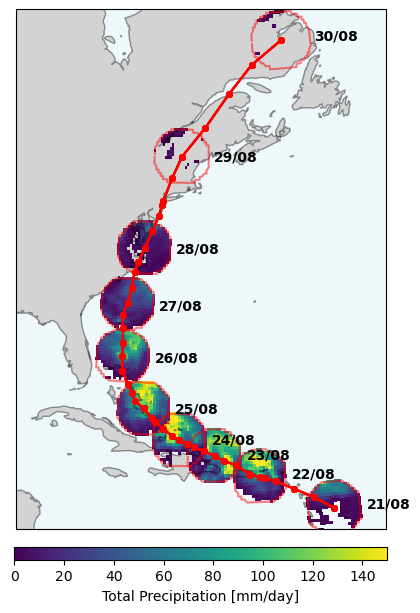

In [35]:
radius_km = 250.0 # Radius from best track
R = 6371.0 

# Define bounding box limits
min_lat, max_lat = 13, 55
min_lon, max_lon = 275, 305

# Create figure with cartopy projection
projection = ccrs.LambertConformal(
    central_longitude=(min_lon+max_lon)/2.0,
    central_latitude=(min_lat+max_lat)/2.0,
    standard_parallels=(20.0, 40.0)
)

# Create base plot
fig, ax = plt.subplots(1, 1, figsize=(6,6), layout='constrained', subplot_kw={'projection': projection})
ax.add_feature(cfeature.COASTLINE, alpha=0.4)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Filter strom data as daily
storm_filtered = [(lat, lon, dt) for lat, lon, dt in zip(storm.lat, storm.lon, storm.time) if dt.hour == 0 and dt.minute == 0 and dt.second == 0 and dt.microsecond == 0]
storm_lat, storm_lon, storm_time = zip(*storm_filtered)
storm_lat = list(storm_lat)
storm_lon = list(storm_lon)
storm_time = list(storm_time)

# Define data structure
data = {
    "CMORPH": [None]*len(storm_time),
    "ERA5": [None]*len(storm_time),
    "AURORA": [None]*len(storm_time)
}

indx = 0
for lat, lon, time in storm_filtered:
    # Load data
    data0 = ds_cmorph.cmorph.sel(time=time,  method="nearest")
    data1 = ds_era5_daily.tp.sel(time=time, method="nearest")/3600*8.64e+7
    data2 = ds_combined_daily.tp.sel(time=time, method="nearest")*8.64e+7

    # find distance, obs grid
    lonp_rad = np.radians(lon)
    latp_rad = np.radians(lat)
    lon0_rad = np.radians(data0.lon)
    lat0_rad = np.radians(data0.lat)
    dlon0 = lonp_rad - lon0_rad
    dlat0 = latp_rad - lat0_rad
    a = np.sin(dlat0/2)**2 + np.cos(latp_rad) * np.cos(lat0_rad) * np.sin(dlon0/2)**2
    c = 2 * np.atan2(np.sqrt(a), np.sqrt(1 - a))
    distance_obs = R*c
    mask_obs = distance_obs < radius_km
    data0_mean = data0.where(mask_obs & (data0 > 0.01), other=np.nan).mean(["lat", "lon"], skipna=True).values
    data["CMORPH"][indx] = data0_mean

    # find distance, era5 grid
    lon1_rad = np.radians(data1.longitude)
    lat1_rad = np.radians(data1.latitude)
    dlon1 = lonp_rad - lon1_rad
    dlat1 = latp_rad - lat1_rad
    a = np.sin(dlat1/2)**2 + np.cos(latp_rad) * np.cos(lat1_rad) * np.sin(dlon1/2)**2
    c = 2 * np.atan2(np.sqrt(a), np.sqrt(1 - a))
    distance_era5 = R*c
    mask_era5 = distance_era5 < radius_km
    data1_mean = data1.where(mask_era5 & (data1 > 1.0), other=np.nan).mean(["latitude", "longitude"], skipna=True).values
    data["ERA5"][indx] = data1_mean

    # find distance, aurora grid
    lon2_rad = np.radians(data2.longitude)
    lat2_rad = np.radians(data2.latitude)
    dlon2 = lonp_rad - lon2_rad
    dlat2 = latp_rad - lat2_rad
    a = np.sin(dlat2/2)**2 + np.cos(latp_rad) * np.cos(lat2_rad) * np.sin(dlon2/2)**2
    c = 2 * np.atan2(np.sqrt(a), np.sqrt(1 - a))
    distance_aurora = R*c
    mask_aurora = distance_aurora < radius_km
    data2_mean = data2.where(mask_aurora & (data2 > 1.0), other=np.nan).mean(["latitude", "longitude"], skipna=True).values
    data["AURORA"][indx] = data2_mean

    # extract edge of selected region, obs grid
    da_edge = xr.DataArray(
        feature.canny(mask_obs),
        coords= {
            'lat':data0.lat,
            'lon':data0.lon
        }
    )
    data0_masked = data0.where(da_edge, drop=True)
    non_nan_mask = ~np.isnan(data0_masked)
    lon2d, lat2d = np.meshgrid(data0_masked.lon, data0_masked.lat)
    lat_edge = lat2d[non_nan_mask]
    lon_edge = lon2d[non_nan_mask]

    # Order points
    points = order_points_by_angle(zip(lon_edge, lat_edge), center=(np.mean(lon_edge), np.mean(lat_edge)))
    lon_edge_ordered, lat_edge_ordered = zip(*points)
    lon_edge_ordered = list(lon_edge_ordered)
    lat_edge_ordered = list(lat_edge_ordered)

    # Plot selected region on map
    ax.plot(lon_edge_ordered, lat_edge_ordered, color='red', alpha = 0.5, transform=ccrs.PlateCarree())
    
    # Plot preciptiation
    lon = ds_cmorph.lon
    lat = ds_cmorph.lat
    d = data0.where(mask_obs & (data0 > 1.0), other=np.nan)
    im = ax.pcolormesh(lon, lat, d, vmin=vmin, vmax=vmax, shading='auto', cmap='viridis', transform=ccrs.PlateCarree())
    
    # Plot best track
    ax.plot(
        storm.lon,
        storm.lat,
        color="red",
        marker="o",
        markersize=4,
        alpha = 0.5,
        #linewidth=2,
        label="HURDAT2",
        transform=ccrs.PlateCarree(),
    )
    
    # Add time information
    x = np.max(lon_edge_ordered)*1.002
    y = np.mean(lat_edge_ordered)
    ax.text(x, y, f'{time_days[indx]}', fontweight='bold', fontsize=10, horizontalalignment='left', verticalalignment='center', multialignment='center', transform=ccrs.PlateCarree())

    indx = indx+1

# Add color bar
fig.colorbar(im, ax=ax, pad=0.03, location="bottom", aspect=30, shrink=0.63, label='Total Precipitation [mm/day]')

# Save figure
filename = f'cmorph_along_track.png'
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

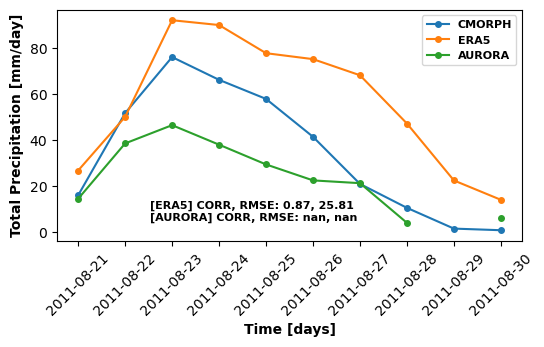

In [36]:
# Get data
corr_era5 = np.corrcoef(np.array(data["CMORPH"]), np.array(data["ERA5"]))[0, 1]
rmse_era5 = np.sqrt(np.mean((np.array(data["CMORPH"]) - np.array(data["ERA5"])) ** 2))
corr_aurora = np.corrcoef(np.array(data["CMORPH"]), np.array(data["AURORA"]))[0, 1]
rmse_aurora = np.sqrt(np.mean((np.array(data["CMORPH"]) - np.array(data["AURORA"])) ** 2))

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(6,3))

# Create plot
ax.plot(storm_time, data["CMORPH"], marker='o', markersize=4, label="CMORPH")
ax.plot(storm_time, data["ERA5"], marker='o', markersize=4, label="ERA5")
ax.plot(storm_time, data["AURORA"], marker='o', markersize=4, label="AURORA")
ax.legend(ncol=1, loc='upper right', prop={'size': 8, 'weight': 'bold'})
ax.set_xlabel('Time [days]', fontsize=10, fontweight='bold')
ax.set_ylabel('Total Precipitation [mm/day]', fontsize=10, fontweight='bold')
ax.tick_params(axis='x', labelrotation=45)

ax.text(0.2, 0.15, f'[ERA5] CORR, RMSE: {corr_era5:.2f}, {rmse_era5:.2f}', fontsize=8, fontweight='bold', horizontalalignment='left', verticalalignment='center', multialignment='center', transform=ax.transAxes)
ax.text(0.2, 0.10, f'[AURORA] CORR, RMSE: {corr_aurora:.2f}, {rmse_aurora:.2f}', fontsize=8, fontweight='bold', horizontalalignment='left', verticalalignment='center', multialignment='center', transform=ax.transAxes)

# Save figure
filename = f'time_series_{lead_time}.png'
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)